In [156]:
pip install pydub

In [157]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from pydub import AudioSegment
from scipy.fft import rfft, rfftfreq
from scipy.io import wavfile

In [158]:
# ==============================
# USER SETTINGS
# ==============================

# Path to your MP3 file
AUDIO_PATH = "audio.mp3"

# Number of strongest Fourier components
TOP_N = 100

# Ignore frequencies below this value
MIN_FREQ = 20.0

# Maximum frequency analyzed/displayed
MAX_FREQ = 5000.0

# FFT window
# "hann" reduces spectral leakage
# "none" uses the original signal
WINDOW_TYPE = "hann"

In [159]:
def load_mp3(path):
    """
    Load an MP3 file and convert it into a normalized
    mono NumPy signal.

    Returns:
        sample_rate : samples per second
        signal      : normalized audio signal
    """

    # Load MP3
    audio = AudioSegment.from_mp3(path)

    # Get sample rate
    sample_rate = audio.frame_rate

    # Convert raw PCM samples into NumPy array
    data = np.array(
        audio.get_array_of_samples()
    )

    # --------------------------------------------------
    # Convert stereo → mono
    # --------------------------------------------------

    if audio.channels > 1:

        data = data.reshape(
            (-1, audio.channels)
        )

        data = data.mean(axis=1)

    # --------------------------------------------------
    # Convert integer PCM → floating point
    # --------------------------------------------------

    if np.issubdtype(
        data.dtype,
        np.integer
    ):

        info = np.iinfo(data.dtype)

        scale = max(
            abs(info.min),
            abs(info.max)
        )

        signal = (
            data.astype(np.float64)
            / scale
        )

    else:

        signal = data.astype(
            np.float64
        )

    # --------------------------------------------------
    # Remove DC offset
    # --------------------------------------------------

    signal -= np.mean(signal)

    # --------------------------------------------------
    # Normalize
    # --------------------------------------------------

    peak = np.max(
        np.abs(signal)
    )

    if peak > 0:
        signal /= peak

    return sample_rate, signal

In [160]:
sample_rate, signal = load_mp3(
    AUDIO_PATH
)

N = len(signal)

duration = N / sample_rate

time = (
    np.arange(N)
    / sample_rate
)

print("=" * 60)
print("AUDIO INFORMATION")
print("=" * 60)

print(f"File:              {AUDIO_PATH}")
print(f"Sample rate:       {sample_rate:,} Hz")
print(f"Samples:           {N:,}")
print(f"Duration:          {duration:.3f} seconds")
print(
    f"Nyquist frequency: "
    f"{sample_rate / 2:,.1f} Hz"
)
print(
    f"FFT resolution:    "
    f"{sample_rate / N:.6f} Hz"
)

AUDIO INFORMATION
File:              audio.mp3
Sample rate:       48,000 Hz
Samples:           8,282,880
Duration:          172.560 seconds
Nyquist frequency: 24,000.0 Hz
FFT resolution:    0.005795 Hz


In [161]:
x = 5 # Time in seconds

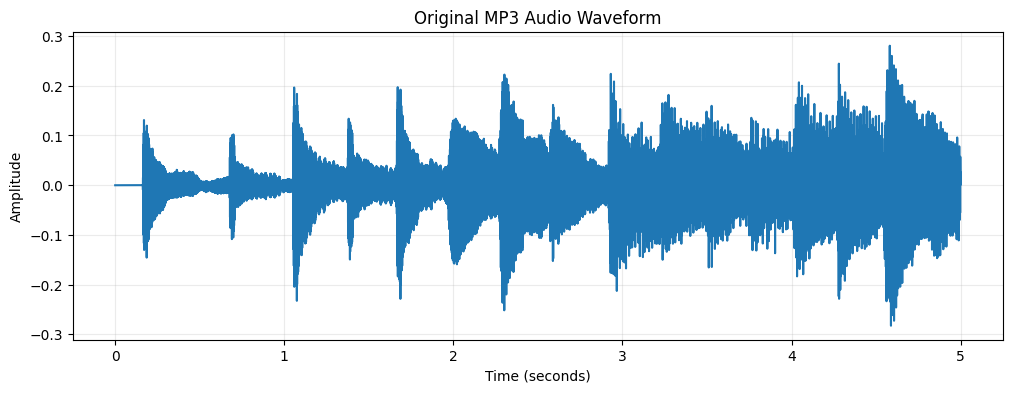

In [162]:
# Display first x seconds
display_time = min(
    x,
    duration
)

mask = time <= display_time

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    time[mask],
    signal[mask]
)

plt.title(
    "Original MP3 Audio Waveform"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Amplitude"
)

plt.grid(
    alpha=0.25
)

plt.show()

In [163]:
def create_window(
    length,
    window_type="hann"
):
    """
    Create the window applied before
    calculating the FFT.
    """

    if window_type == "hann":

        return np.hanning(
            length
        )

    elif window_type == "none":

        return np.ones(
            length
        )

    else:

        raise ValueError(
            "window_type must be "
            "'hann' or 'none'"
        )

In [164]:
def compute_fft(
    signal,
    sample_rate,
    window_type="hann"
):
    """
    Calculate the one-sided FFT.

    Returns:
        frequencies
        amplitudes
        phases
        spectrum
    """

    N = len(signal)

    # --------------------------------------------------
    # Apply window
    # --------------------------------------------------

    window = create_window(
        N,
        window_type
    )

    windowed_signal = (
        signal * window
    )

    # --------------------------------------------------
    # Fourier Transform
    # --------------------------------------------------

    spectrum = rfft(
        windowed_signal
    )

    # Frequency corresponding
    # to each FFT bin
    frequencies = rfftfreq(
        N,
        d=1 / sample_rate
    )

    # --------------------------------------------------
    # Calculate amplitudes
    # --------------------------------------------------

    coherent_gain = np.mean(
        window
    )

    amplitudes = (
        np.abs(spectrum)
        / (N * coherent_gain)
    )

    # rFFT contains only positive
    # frequencies, so double the
    # non-DC components.
    if N > 1:

        amplitudes[1:-1] *= 2

    # --------------------------------------------------
    # Calculate phase
    # --------------------------------------------------

    # FFT naturally produces:
    #
    # A cos(2πft + θ)
    #
    # We want:
    #
    # A sin(2πft + φ)
    #
    # Since:
    #
    # cos(x) = sin(x + π/2)
    #
    # φ = θ + π/2

    phases = (
        np.angle(spectrum)
        + np.pi / 2
    )

    # Keep phase between -π and π
    phases = (
        (phases + np.pi)
        % (2 * np.pi)
        - np.pi
    )

    return (
        frequencies,
        amplitudes,
        phases,
        spectrum
    )

In [165]:
frequencies, amplitudes, phases, spectrum = (
    compute_fft(
        signal,
        sample_rate,
        WINDOW_TYPE
    )
)

print(
    f"FFT bins: {len(frequencies):,}"
)

print(
    f"Frequency resolution: "
    f"{sample_rate / N:.6f} Hz"
)

FFT bins: 4,141,441
Frequency resolution: 0.005795 Hz


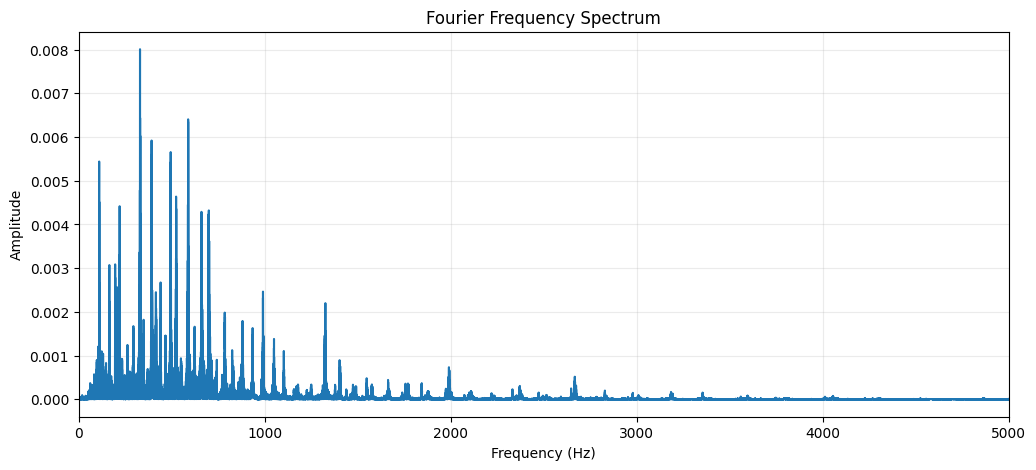

In [166]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    frequencies,
    amplitudes
)

plt.xlim(
    0,
    min(
        MAX_FREQ,
        frequencies[-1]
    )
)

plt.title(
    "Fourier Frequency Spectrum"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Amplitude"
)

plt.grid(
    alpha=0.25
)

plt.show()

In [167]:
@dataclass
class Wave:

    frequency: float
    amplitude: float
    phase: float
    fft_index: int

In [168]:
def get_dominant_waves(
    frequencies,
    amplitudes,
    phases,
    top_n=10,
    min_freq=20,
    max_freq=None
):
    """
    Find the strongest Fourier components
    within the selected frequency range.
    """

    if max_freq is None:

        max_freq = frequencies[-1]

    # Select valid frequencies
    valid = (
        (frequencies >= min_freq)
        & (frequencies <= max_freq)
        & (frequencies > 0)
    )

    valid_indices = (
        np.flatnonzero(valid)
    )

    if len(valid_indices) == 0:

        return []

    # Sort by amplitude
    sorted_indices = valid_indices[
        np.argsort(
            amplitudes[
                valid_indices
            ]
        )[::-1]
    ]

    # Select strongest components
    selected = (
        sorted_indices[:top_n]
    )

    waves = []

    for index in selected:

        waves.append(
            Wave(
                frequency=float(
                    frequencies[index]
                ),

                amplitude=float(
                    amplitudes[index]
                ),

                phase=float(
                    phases[index]
                ),

                fft_index=int(index)
            )
        )

    # Sort by frequency
    waves.sort(
        key=lambda wave:
        wave.frequency
    )

    return waves

In [169]:
waves = get_dominant_waves(
    frequencies,
    amplitudes,
    phases,
    top_n=TOP_N,
    min_freq=MIN_FREQ,
    max_freq=MAX_FREQ
)

print(
    f"Extracted {len(waves)} "
    f"dominant frequency components."
)

Extracted 100 dominant frequency components.


In [170]:
print(
    f"{'Wave':>6}"
    f"{'Frequency (Hz)':>20}"
    f"{'Amplitude':>15}"
    f"{'Phase (rad)':>15}"
)

print("-" * 60)

for i, wave in enumerate(
    waves,
    start=1
):

    print(
        f"{i:>6}"
        f"{wave.frequency:>20.3f}"
        f"{wave.amplitude:>15.6f}"
        f"{wave.phase:>15.6f}"
    )

  Wave      Frequency (Hz)      Amplitude    Phase (rad)
------------------------------------------------------------
     1             109.689       0.004697       0.086185
     2             109.724       0.005438      -2.855249
     3             109.811       0.004516      -2.756214
     4             328.697       0.004782       1.219731
     5             328.807       0.004678       0.835896
     6             328.848       0.004553      -2.884553
     7             328.900       0.006823      -1.205415
     8             328.917       0.005480      -2.605129
     9             328.923       0.005537       0.102247
    10             328.946       0.004879       0.004112
    11             329.016       0.005326      -0.985365
    12             329.057       0.004623      -2.343277
    13             329.074       0.006809      -0.811803
    14             329.080       0.005334       2.492169
    15             329.115       0.004854      -2.414718
    16             329.120 

In [171]:
def print_wave_functions(waves):

    print()
    print("=" * 75)
    print(
        "DOMINANT SINE WAVE FUNCTIONS"
    )
    print("=" * 75)

    print(
        "\nx(t) ≈ "
        "Σ Aᵢ sin(2π fᵢ t + φᵢ)\n"
    )

    for i, wave in enumerate(
        waves,
        start=1
    ):

        if wave.phase >= 0:

            sign = "+"
            phase = wave.phase

        else:

            sign = "-"
            phase = abs(
                wave.phase
            )

        print(
            f"Wave {i:2d}: "
            f"{wave.amplitude:.6f} × "
            f"sin(2π × "
            f"{wave.frequency:.3f} × t "
            f"{sign} {phase:.4f})"
        )

In [172]:
print_wave_functions(
    waves
)


DOMINANT SINE WAVE FUNCTIONS

x(t) ≈ Σ Aᵢ sin(2π fᵢ t + φᵢ)

Wave  1: 0.004697 × sin(2π × 109.689 × t + 0.0862)
Wave  2: 0.005438 × sin(2π × 109.724 × t - 2.8552)
Wave  3: 0.004516 × sin(2π × 109.811 × t - 2.7562)
Wave  4: 0.004782 × sin(2π × 328.697 × t + 1.2197)
Wave  5: 0.004678 × sin(2π × 328.807 × t + 0.8359)
Wave  6: 0.004553 × sin(2π × 328.848 × t - 2.8846)
Wave  7: 0.006823 × sin(2π × 328.900 × t - 1.2054)
Wave  8: 0.005480 × sin(2π × 328.917 × t - 2.6051)
Wave  9: 0.005537 × sin(2π × 328.923 × t + 0.1022)
Wave 10: 0.004879 × sin(2π × 328.946 × t + 0.0041)
Wave 11: 0.005326 × sin(2π × 329.016 × t - 0.9854)
Wave 12: 0.004623 × sin(2π × 329.057 × t - 2.3433)
Wave 13: 0.006809 × sin(2π × 329.074 × t - 0.8118)
Wave 14: 0.005334 × sin(2π × 329.080 × t + 2.4922)
Wave 15: 0.004854 × sin(2π × 329.115 × t - 2.4147)
Wave 16: 0.005578 × sin(2π × 329.120 × t + 0.6042)
Wave 17: 0.004735 × sin(2π × 329.126 × t - 2.8190)
Wave 18: 0.005632 × sin(2π × 329.132 × t + 0.4082)
Wave 19: 0.004613 × 

In [173]:
def reconstruct_from_waves(
    waves,
    num_samples,
    sample_rate
):
    """
    Reconstruct the audio by directly summing
    the extracted sine functions.

    x(t) = Σ Aᵢ sin(2πfᵢt + φᵢ)
    """

    t = (
        np.arange(num_samples)
        / sample_rate
    )

    reconstructed = np.zeros(
        num_samples,
        dtype=np.float64
    )

    for wave in waves:

        reconstructed += (
            wave.amplitude
            * np.sin(
                2 * np.pi
                * wave.frequency
                * t
                + wave.phase
            )
        )

    return t, reconstructed

In [174]:
reconstructed_time, reconstructed = (
    reconstruct_from_waves(
        waves,
        N,
        sample_rate
    )
)

# Normalize only for visualization
peak = np.max(
    np.abs(reconstructed)
)

if peak > 1:

    reconstructed_plot = (
        reconstructed / peak
    )

else:

    reconstructed_plot = (
        reconstructed
    )

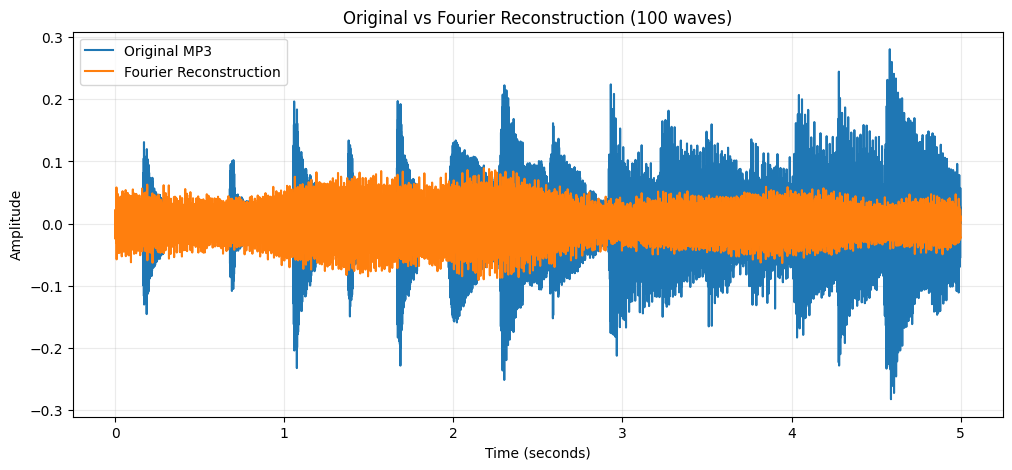

In [175]:
display_time = min(
    x,
    duration
)

original_mask = (
    time <= display_time
)

reconstructed_mask = (
    reconstructed_time
    <= display_time
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    time[original_mask],
    signal[original_mask],
    label="Original MP3"
)

plt.plot(
    reconstructed_time[
        reconstructed_mask
    ],
    reconstructed_plot[
        reconstructed_mask
    ],
    label="Fourier Reconstruction"
)

plt.title(
    f"Original vs Fourier Reconstruction "
    f"({len(waves)} waves)"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Amplitude"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

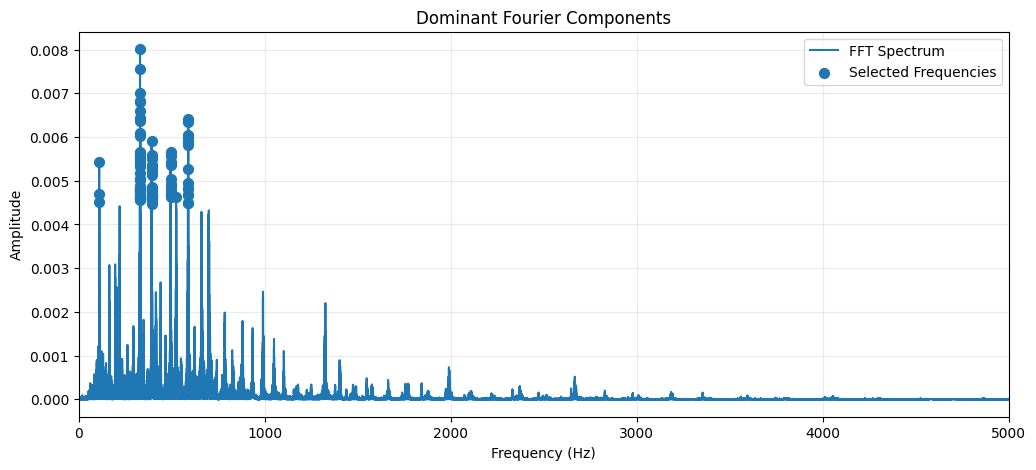

In [176]:
selected_frequencies = [
    wave.frequency
    for wave in waves
]

selected_amplitudes = [
    wave.amplitude
    for wave in waves
]

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    frequencies,
    amplitudes,
    label="FFT Spectrum"
)

plt.scatter(
    selected_frequencies,
    selected_amplitudes,
    s=50,
    label="Selected Frequencies",
    zorder=3
)

plt.xlim(
    0,
    min(
        MAX_FREQ,
        frequencies[-1]
    )
)

plt.title(
    "Dominant Fourier Components"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Amplitude"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

In [177]:
def calculate_error(
    original,
    reconstructed
):
    """
    Calculate MSE and RMSE.
    """

    error = (
        original
        - reconstructed
    )

    mse = np.mean(
        error ** 2
    )

    rmse = np.sqrt(
        mse
    )

    return mse, rmse

In [178]:
# Normalize reconstruction
reconstruction_peak = np.max(
    np.abs(reconstructed)
)

if reconstruction_peak > 0:

    reconstructed_normalized = (
        reconstructed
        / reconstruction_peak
    )

else:

    reconstructed_normalized = (
        reconstructed
    )

mse, rmse = calculate_error(
    signal,
    reconstructed_normalized
)

print(
    f"Mean Squared Error: "
    f"{mse:.8f}"
)

print(
    f"Root Mean Squared Error: "
    f"{rmse:.8f}"
)

Mean Squared Error: 0.02399708
Root Mean Squared Error: 0.15490989


In [179]:
def save_wav(
    path,
    sample_rate,
    signal
):
    """
    Save a floating-point signal
    as a 16-bit PCM WAV file.
    """

    signal = np.asarray(
        signal,
        dtype=np.float64
    )

    peak = np.max(
        np.abs(signal)
    )

    if peak > 0:

        signal = (
            signal / peak
        )

    signal = np.clip(
        signal,
        -1,
        1
    )

    pcm = np.round(
        signal * 32767
    ).astype(np.int16)

    wavfile.write(
        path,
        sample_rate,
        pcm
    )

In [180]:
OUTPUT_AUDIO = (
    "fourier_reconstruction.wav"
)

save_wav(
    OUTPUT_AUDIO,
    sample_rate,
    reconstructed
)

print(
    f"Saved reconstruction to: "
    f"{OUTPUT_AUDIO}"
)

Saved reconstruction to: fourier_reconstruction.wav


In [181]:
def save_wave_functions(
    path,
    waves
):

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as file:

        file.write(
            "Fourier Audio Decomposition\n"
        )

        file.write(
            "=" * 60 + "\n\n"
        )

        file.write(
            "x(t) ≈ "
            "Σ Aᵢ sin(2π fᵢ t + φᵢ)\n\n"
        )

        for i, wave in enumerate(
            waves,
            start=1
        ):

            if wave.phase >= 0:

                sign = "+"
                phase = wave.phase

            else:

                sign = "-"
                phase = abs(
                    wave.phase
                )

            file.write(
                f"Wave {i}: "
                f"{wave.amplitude:.8f} × "
                f"sin(2π × "
                f"{wave.frequency:.6f} × t "
                f"{sign} {phase:.6f})\n"
            )

In [182]:
EQUATION_FILE = (
    "fourier_waves.txt"
)

save_wave_functions(
    EQUATION_FILE,
    waves
)

print(
    f"Saved equations to: "
    f"{EQUATION_FILE}"
)

Saved equations to: fourier_waves.txt


In [183]:
wave_counts = [
    1,
    5,
    10,
    25,
    50,
    100
]

results = []

for count in wave_counts:

    test_waves = (
        get_dominant_waves(
            frequencies,
            amplitudes,
            phases,
            top_n=count,
            min_freq=MIN_FREQ,
            max_freq=MAX_FREQ
        )
    )

    _, test_reconstruction = (
        reconstruct_from_waves(
            test_waves,
            N,
            sample_rate
        )
    )

    # Normalize
    peak = np.max(
        np.abs(test_reconstruction)
    )

    if peak > 0:

        test_reconstruction /= peak

    _, test_rmse = (
        calculate_error(
            signal,
            test_reconstruction
        )
    )

    results.append(
        test_rmse
    )

    print(
        f"{count:3d} waves → "
        f"RMSE = {test_rmse:.6f}"
    )

  1 waves → RMSE = 0.709648
  5 waves → RMSE = 0.344147
 10 waves → RMSE = 0.270579
 25 waves → RMSE = 0.222589
 50 waves → RMSE = 0.203012
100 waves → RMSE = 0.154910


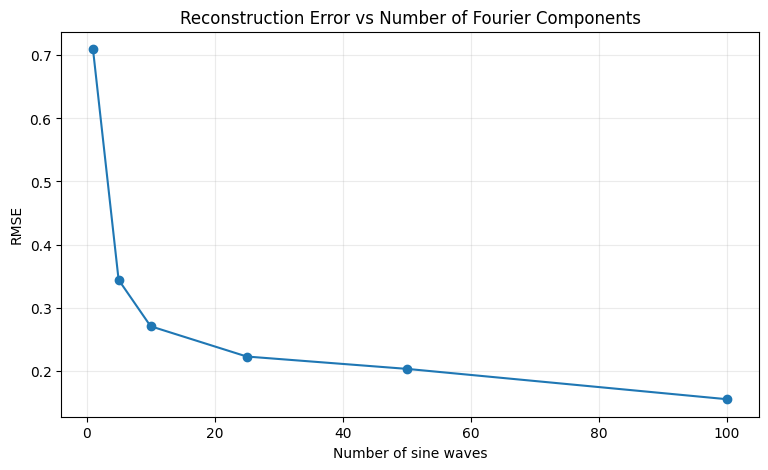

In [184]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    wave_counts,
    results,
    marker="o"
)

plt.title(
    "Reconstruction Error vs Number of Fourier Components"
)

plt.xlabel(
    "Number of sine waves"
)

plt.ylabel(
    "RMSE"
)

plt.grid(
    alpha=0.25
)

plt.show()

In [185]:
def build_equation(waves):

    terms = []

    for wave in waves:

        if wave.phase >= 0:

            sign = "+"
            phase = wave.phase

        else:

            sign = "-"
            phase = abs(
                wave.phase
            )

        term = (
            f"{wave.amplitude:.6f}"
            f"·sin(2π·"
            f"{wave.frequency:.3f}t "
            f"{sign} "
            f"{phase:.4f})"
        )

        terms.append(term)

    return (
        "x(t) ≈ "
        + " + ".join(terms)
    )

In [186]:
equation = build_equation(
    waves
)

print(equation)

x(t) ≈ 0.004697·sin(2π·109.689t + 0.0862) + 0.005438·sin(2π·109.724t - 2.8552) + 0.004516·sin(2π·109.811t - 2.7562) + 0.004782·sin(2π·328.697t + 1.2197) + 0.004678·sin(2π·328.807t + 0.8359) + 0.004553·sin(2π·328.848t - 2.8846) + 0.006823·sin(2π·328.900t - 1.2054) + 0.005480·sin(2π·328.917t - 2.6051) + 0.005537·sin(2π·328.923t + 0.1022) + 0.004879·sin(2π·328.946t + 0.0041) + 0.005326·sin(2π·329.016t - 0.9854) + 0.004623·sin(2π·329.057t - 2.3433) + 0.006809·sin(2π·329.074t - 0.8118) + 0.005334·sin(2π·329.080t + 2.4922) + 0.004854·sin(2π·329.115t - 2.4147) + 0.005578·sin(2π·329.120t + 0.6042) + 0.004735·sin(2π·329.126t - 2.8190) + 0.005632·sin(2π·329.132t + 0.4082) + 0.004613·sin(2π·329.138t - 2.7086) + 0.004804·sin(2π·329.155t + 1.7264) + 0.004762·sin(2π·329.178t + 0.3967) + 0.006603·sin(2π·329.184t + 2.9068) + 0.007548·sin(2π·329.190t - 0.2325) + 0.007009·sin(2π·329.196t - 2.7163) + 0.004590·sin(2π·329.225t + 1.1918) + 0.006100·sin(2π·329.248t - 0.1305) + 0.008008·sin(2π·329.259t + 2.93

In [187]:
print("=" * 70)
print("FOURIER AUDIO ANALYSIS COMPLETE")
print("=" * 70)

print("\nINPUT")
print(
    f"  File: {AUDIO_PATH}"
)
print(
    f"  Sample rate: "
    f"{sample_rate:,} Hz"
)
print(
    f"  Duration: "
    f"{duration:.3f} seconds"
)
print(
    f"  Samples: "
    f"{N:,}"
)

print("\nFOURIER MODEL")
print(
    f"  Components: "
    f"{len(waves)}"
)
print(
    f"  Frequency range: "
    f"{MIN_FREQ}–{MAX_FREQ} Hz"
)
print(
    f"  Resolution: "
    f"{sample_rate / N:.6f} Hz"
)

print("\nRECONSTRUCTION")
print(
    f"  RMSE: "
    f"{rmse:.8f}"
)

print("\nMATHEMATICAL FORM")
print(
    "  x(t) ≈ "
    "Σ Aᵢ sin(2πfᵢt + φᵢ)"
)

FOURIER AUDIO ANALYSIS COMPLETE

INPUT
  File: audio.mp3
  Sample rate: 48,000 Hz
  Duration: 172.560 seconds
  Samples: 8,282,880

FOURIER MODEL
  Components: 100
  Frequency range: 20.0–5000.0 Hz
  Resolution: 0.005795 Hz

RECONSTRUCTION
  RMSE: 0.15490989

MATHEMATICAL FORM
  x(t) ≈ Σ Aᵢ sin(2πfᵢt + φᵢ)
